In [16]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


# Collected Experimental Data

## 1. Experimental Data of E. coli

C:\Users\huang\AppData\Local\Temp\ipykernel_12276\1220256328.py:47: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(sub[xcol], sub[ycol],
C:\Users\huang\AppData\Local\Temp\ipykernel_12276\1220256328.py:47: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(sub[xcol], sub[ycol],
C:\Users\huang\AppData\Local\Temp\ipykernel_12276\1220256328.py:47: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(sub[xcol], sub[ycol],
C:\Users\huang\AppData\Local\Temp\ipykernel_12276\1220256328.py:47: UserWarning: You passed a edgecolor/edgecolors ('k') 

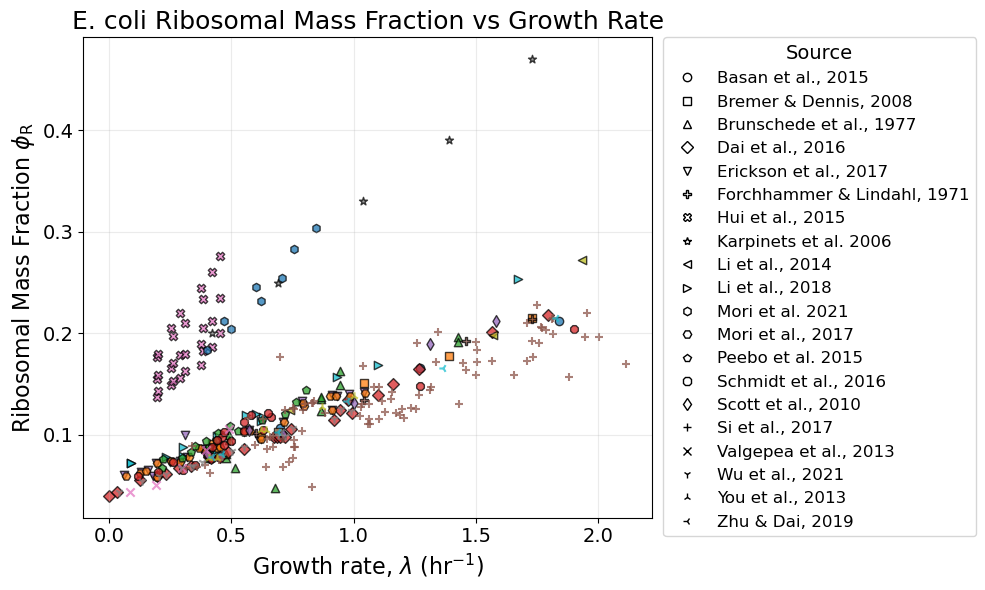

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

# ---- config ----
# Changed the leading slash to a relative path
CSV_PATH = "ecoli_ribosomal_mass_fractions.csv"
xcol = "growth_rate_hr"
ycol = "mass_fraction"
group_col = "source"

# A pool of distinct marker styles (matplotlib built-ins)
MARKERS = [
    "o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H",
    "p", "8", "d", "+", "x", "1", "2", "3", "4"
]

# ---- load + basic cleanup ----
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Could not find {CSV_PATH}. Ensure it is in the same directory as the notebook.")

df = pd.read_csv(CSV_PATH)

# Keep only what we need and coerce to numeric (in case of stray whitespace)
plot_df = df[[xcol, ycol, group_col]].copy()
plot_df[xcol] = pd.to_numeric(plot_df[xcol], errors="coerce")
plot_df[ycol] = pd.to_numeric(plot_df[ycol], errors="coerce")
plot_df = plot_df.dropna(subset=[xcol, ycol, group_col])

# ---- assign markers per source ----
sources = sorted(plot_df[group_col].unique())
if len(sources) > len(MARKERS):
    raise ValueError(
        f"Too many sources ({len(sources)}) for marker pool ({len(MARKERS)}). "
        "Add more markers or reduce categories."
    )

marker_map = {src: MARKERS[i] for i, src in enumerate(sources)}

# ---- plot ----
plt.figure(figsize=(10, 6))

# Plot each source as its own scatter (lets us vary marker by source)
for src in sources:
    sub = plot_df[plot_df[group_col] == src]
    plt.scatter(sub[xcol], sub[ycol],
                marker=marker_map[src],
                edgecolors="k",
                alpha=0.75)

plt.xlabel(r"Growth rate, $\lambda$ (hr$^{-1}$)", fontsize=16)
plt.ylabel(r"Ribosomal Mass Fraction $\phi_{\text{R}}$", fontsize=16)
plt.title(r"E. coli Ribosomal Mass Fraction vs Growth Rate", fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True, alpha=0.25)

# ---- legend (marker-only handles) ----
handles = [
    Line2D([0], [0],
           marker=marker_map[src],
           linestyle="None",
           markeredgecolor="k",
           markerfacecolor="none",
           label=src)
    for src in sources
]

# Put legend outside if there are many sources
plt.legend(handles=handles, title="Source",
           bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.,
           fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()

## 2. Experimental Data of Budding Yeast

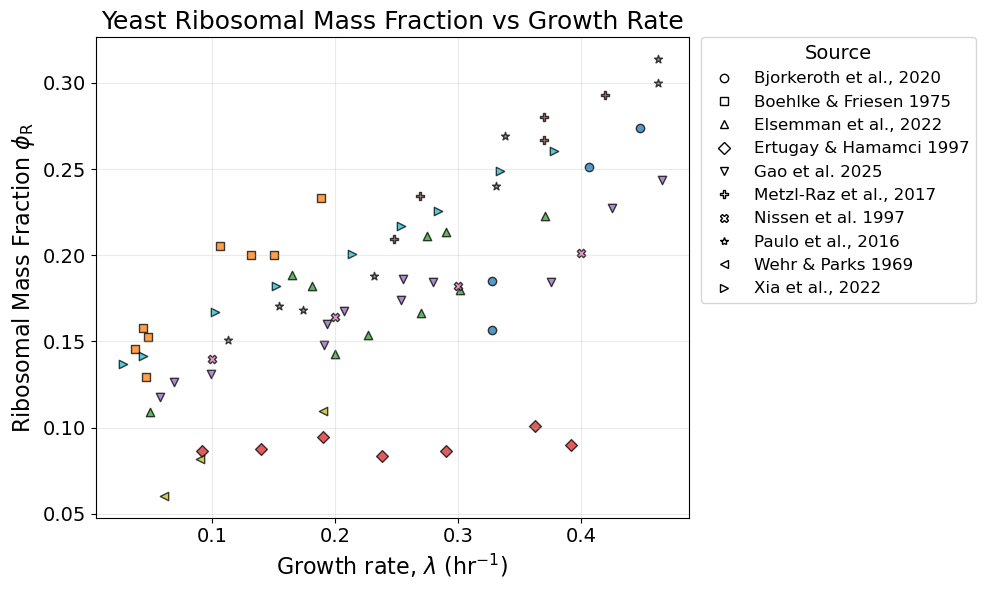

In [24]:
# ---- config ----
# Changed the leading slash to a relative path
CSV_PATH = "yeast_ribosomal_mass_fractions.csv"
xcol = "growth_rate_hr"
ycol = "mass_fraction"
group_col = "source"

# A pool of distinct marker styles (matplotlib built-ins)
MARKERS = [
    "o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H",
    "p", "8", "d", "|", "_", "+", "x", "1", "2", "3", "4"
]

# ---- load + basic cleanup ----
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Could not find {CSV_PATH}. Ensure it is in the same directory as the notebook.")

df = pd.read_csv(CSV_PATH)

# Keep only what we need and coerce to numeric (in case of stray whitespace)
plot_df = df[[xcol, ycol, group_col]].copy()
plot_df[xcol] = pd.to_numeric(plot_df[xcol], errors="coerce")
plot_df[ycol] = pd.to_numeric(plot_df[ycol], errors="coerce")
plot_df = plot_df.dropna(subset=[xcol, ycol, group_col])

# ---- assign markers per source ----
sources = sorted(plot_df[group_col].unique())
if len(sources) > len(MARKERS):
    raise ValueError(
        f"Too many sources ({len(sources)}) for marker pool ({len(MARKERS)}). "
        "Add more markers or reduce categories."
    )

marker_map = {src: MARKERS[i] for i, src in enumerate(sources)}

# ---- plot ----
plt.figure(figsize=(10, 6))

# Plot each source as its own scatter (lets us vary marker by source)
for src in sources:
    sub = plot_df[plot_df[group_col] == src]
    plt.scatter(sub[xcol], sub[ycol],
                marker=marker_map[src],
                edgecolors="k",
                alpha=0.75)

plt.xlabel(r"Growth rate, $\lambda$ (hr$^{-1}$)", fontsize=16)
plt.ylabel(r"Ribosomal Mass Fraction $\phi_{\text{R}}$", fontsize=16)
plt.title(r"Yeast Ribosomal Mass Fraction vs Growth Rate", fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True, alpha=0.25)

# ---- legend (marker-only handles) ----
handles = [
    Line2D([0], [0],
           marker=marker_map[src],
           linestyle="None",
           markeredgecolor="k",
           markerfacecolor="none",
           label=src)
    for src in sources
]

# Put legend outside if there are many sources
plt.legend(handles=handles, title="Source",
           bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.,
           fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()

## 3. Experimental Data of Marine Algae/Diatoms

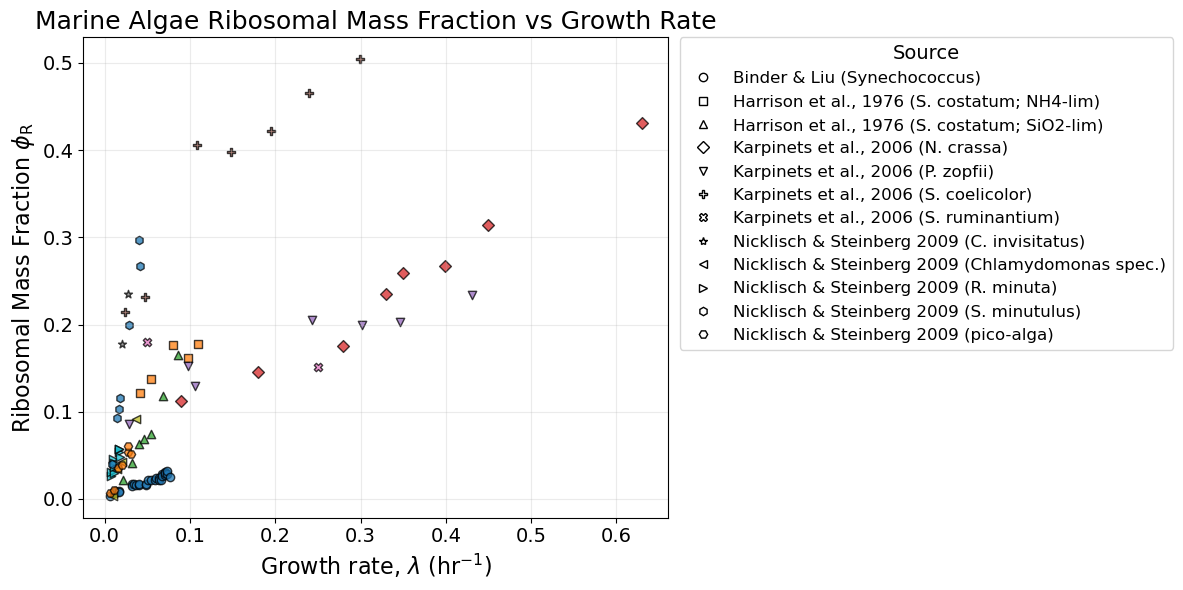

In [19]:
# ---- config ----
# Changed the leading slash to a relative path
CSV_PATH = "marine_algae_ribosomal_mass_fractions.csv"
xcol = "growth_rate_hr"
ycol = "mass_fraction"
group_col = "source"

# A pool of distinct marker styles (matplotlib built-ins)
MARKERS = [
    "o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H",
    "p", "8", "d", "|", "_", "+", "x", "1", "2", "3", "4"
]

# ---- load + basic cleanup ----
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Could not find {CSV_PATH}. Ensure it is in the same directory as the notebook.")

df = pd.read_csv(CSV_PATH)

# Keep only what we need and coerce to numeric (in case of stray whitespace)
plot_df = df[[xcol, ycol, group_col]].copy()
plot_df[xcol] = pd.to_numeric(plot_df[xcol], errors="coerce")
plot_df[ycol] = pd.to_numeric(plot_df[ycol], errors="coerce")
plot_df = plot_df.dropna(subset=[xcol, ycol, group_col])

# ---- assign markers per source ----
sources = sorted(plot_df[group_col].unique())
if len(sources) > len(MARKERS):
    raise ValueError(
        f"Too many sources ({len(sources)}) for marker pool ({len(MARKERS)}). "
        "Add more markers or reduce categories."
    )

marker_map = {src: MARKERS[i] for i, src in enumerate(sources)}

# ---- plot ----
plt.figure(figsize=(12, 6))

# Plot each source as its own scatter (lets us vary marker by source)
for src in sources:
    sub = plot_df[plot_df[group_col] == src]
    plt.scatter(sub[xcol], sub[ycol],
                marker=marker_map[src],
                edgecolors="k",
                alpha=0.75)

plt.xlabel(r"Growth rate, $\lambda$ (hr$^{-1}$)", fontsize=16)
plt.ylabel(r"Ribosomal Mass Fraction $\phi_{\text{R}}$", fontsize=16)
plt.title(r"Marine Algae Ribosomal Mass Fraction vs Growth Rate", fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True, alpha=0.25)

# ---- legend (marker-only handles) ----
handles = [
    Line2D([0], [0],
           marker=marker_map[src],
           linestyle="None",
           markeredgecolor="k",
           markerfacecolor="none",
           label=src)
    for src in sources
]

# Put legend outside if there are many sources
plt.legend(handles=handles, title="Source",
           bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.,
           fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()

## Fit to Theory

$$
\theta_1 \sim 1 - A \sqrt{b}, \quad \theta_2 \sim \sqrt{\frac{k_1}{a_1}} \sqrt{b}\quad \theta_3 \sim \sqrt{\frac{k_2}{a_2}} \sqrt{b}.
$$

Fit results (positive):
  k1 = 5.63634
  k2 = 0.771815
  a1 = 1.96738
  a2 = 9.65019
  R^2 = 0.4231
Approx. 1σ errors:
  k1: 4.32e+07, k2: nan, a1: 2.18e+07, a2: nan


C:\Users\huang\AppData\Local\Temp\ipykernel_12276\3714257363.py:95: RuntimeWarning: invalid value encountered in sqrt
  se_logp = np.sqrt(np.diag(cov_logp))


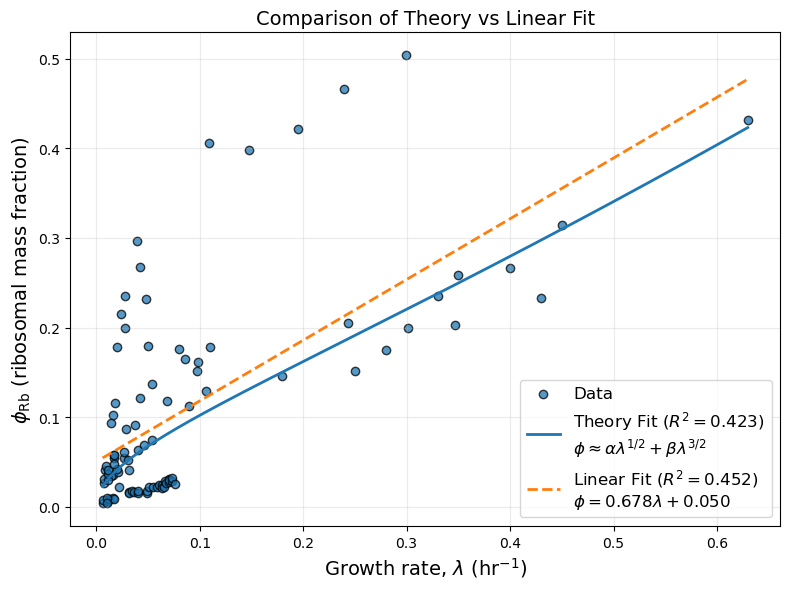

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# -----------------------
# 1) pull x,y from plot_df
# -----------------------
x = plot_df[xcol].to_numpy(dtype=float)  # lambda_arr_exp
y = plot_df[ycol].to_numpy(dtype=float)  # Y5_arr_exp

mask = np.isfinite(x) & np.isfinite(y) & (x > 0)  # need lambda>0 for sqrt
x = x[mask]
y = y[mask]

# OPTIONAL: since this is a low-lambda expansion, you may want to only fit small lambda.
# Set e.g. lambda_max = 0.8 (or whatever makes sense for your data)
lambda_max = None
if lambda_max is not None:
    keep = x <= lambda_max
    x, y = x[keep], y[keep]

# -----------------------
# 2) model: Y5(lambda; k1,k2,a1,a2)
# -----------------------
def y5_model(lam, k1, k2, a1, a2):
    # ratios
    u1 = k1 / a1
    u2 = k2 / a2

    A = np.sqrt(u1) + np.sqrt(u2)
    C = u1 + u2
    D = 1.0 / a1 + 1.0 / a2
    E = np.sqrt(u1 * u2)

    alpha = np.sqrt(u2)  # sqrt(k2/a2)

    # original coefficient as you wrote it:
    beta = 0.125 * alpha * (3.0 * A * A - 2.0 * E + C - 4.0 * D)

    # equivalent simplified form (uncomment to use):
    # beta = 0.5 * alpha * (C + E - D)

    return alpha * np.sqrt(lam) + beta * lam * np.sqrt(lam)  # lambda^(1/2) + beta*lambda^(3/2)

# -----------------------
# 3) fit with positivity enforced via log-parameters
# -----------------------
def residuals(logp):
    k1, k2, a1, a2 = np.exp(logp)   # strictly positive
    return y5_model(x, k1, k2, a1, a2) - y

# crude initial guess from leading-order slope: y ≈ alpha*sqrt(lambda)
s = np.sqrt(x)
alpha0 = (s @ y) / (s @ s)
u2_0 = max(alpha0, 1e-12) ** 2          # u2 = k2/a2
logp0 = np.log([u2_0, u2_0, 1.0, 1.0])  # k1~k2~u2_0, a1~a2~1

res = least_squares(
    residuals,
    logp0,
    bounds=(-30, 30),     # wide bounds in log-space
    loss="soft_l1",       # robust to outliers; change to "linear" for plain LS
    f_scale=0.01
)

k1_fit, k2_fit, a1_fit, a2_fit = np.exp(res.x)

# -----------------------
# 4) diagnostics + plot
# -----------------------
yhat = y5_model(x, k1_fit, k2_fit, a1_fit, a2_fit)
ss_res = np.sum((y - yhat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# --- NEW: Linear Fit ---
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r2_lin = r_value**2
y_lin_fit = slope * x + intercept

print("Fit results (positive):")
print(f"  k1 = {k1_fit:.6g}")
print(f"  k2 = {k2_fit:.6g}")
print(f"  a1 = {a1_fit:.6g}")
print(f"  a2 = {a2_fit:.6g}")
print(f"  R^2 = {r2:.4f}")

# Approx. standard errors (may be unstable if problem is ill-conditioned)
try:
    J = res.jac
    dof = max(1, len(y) - len(res.x))
    s_sq = np.sum(res.fun**2) / dof
    cov_logp = np.linalg.inv(J.T @ J) * s_sq
    se_logp = np.sqrt(np.diag(cov_logp))
    params = np.array([k1_fit, k2_fit, a1_fit, a2_fit])
    se_params = params * se_logp  # delta(exp) approx
    print("Approx. 1σ errors:")
    print(f"  k1: {se_params[0]:.3g}, k2: {se_params[1]:.3g}, a1: {se_params[2]:.3g}, a2: {se_params[3]:.3g}")
except Exception as e:
    print("Could not estimate standard errors (often due to ill-conditioning):", e)

# Plot fit curve on top of data
lam_grid = np.linspace(np.min(x), np.max(x), 400)
plt.figure(figsize=(8, 6))
plt.scatter(x, y, edgecolors="k", alpha=0.75, label="Data")

# Non-linear fit curve
plt.plot(lam_grid, y5_model(lam_grid, k1_fit, k2_fit, a1_fit, a2_fit), linewidth=2, color='tab:blue',
         label=f"Theory Fit ($R^2={r2:.3f}$)\n$\\phi \\approx \\alpha\\lambda^{{1/2}} + \\beta\\lambda^{{3/2}}$")

# Linear fit curve
plt.plot(lam_grid, slope * lam_grid + intercept, "--", linewidth=2, color='tab:orange',
         label=f"Linear Fit ($R^2={r2_lin:.3f}$)\n$\\phi = {slope:.3f}\\lambda + {intercept:.3f}$")

plt.xlabel(r"Growth rate, $\lambda$ (hr$^{-1}$)", fontsize=14)
plt.ylabel(r"$\phi_{\text{Rb}}$ (ribosomal mass fraction)", fontsize=14)
plt.title(r"Comparison of Theory vs Linear Fit", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Fit to Simplified Model

$$
y = \sqrt{\frac{k}{a}} \sqrt{\lambda} + \frac{1-k}{a} \lambda
$$

Simplified Model Fit Results:
  k = 9.10808
  a = 33.6042
  R^2 = 0.3350
Linear Fit Results:
  slope = 0.307704
  intercept = 0.107893
  R^2 = 0.4282


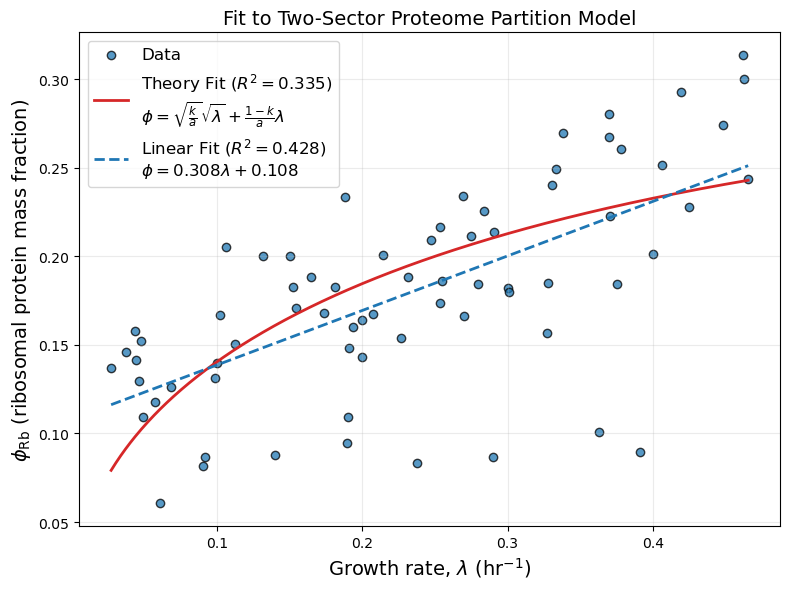

In [25]:
# -----------------------
# Fit to simplified model:
# y = sqrt(k/a)*sqrt(lambda) + ((1-k)/a)*lambda
# -----------------------

# Re-extract x,y from plot_df to ensure this cell is self-contained
# (Assumes plot_df is already defined from previous cells)
if 'plot_df' in locals():
    x_new = plot_df[xcol].to_numpy(dtype=float)
    y_new = plot_df[ycol].to_numpy(dtype=float)
    mask_new = np.isfinite(x_new) & np.isfinite(y_new) & (x_new > 0)
    x_new = x_new[mask_new]
    y_new = y_new[mask_new]
else:
    # If plot_df is not there, try using x, y from previous cell if available
    x_new, y_new = x, y

def model_simple(lam, k, a):
    # y = sqrt(k/a) * sqrt(lambda) + ((1-k)/a) * lambda
    term1 = np.sqrt(k / a) * np.sqrt(lam)
    term2 = ((1.0 - k) / a) * lam
    return term1 + term2

def residuals_simple(logp):
    # Enforce k, a > 0 via log-transform
    k, a = np.exp(logp)
    return model_simple(x_new, k, a) - y_new

# Initial guess
# k ~ 0.5 (dimensionless)
# a ~ 1.0 (time unit inverse?) or match scale
# Just use generic guess
logp0_simple = np.log([0.5, 1.0])

res_simple = least_squares(
    residuals_simple,
    logp0_simple,
    bounds=(-30, 30),
    loss="soft_l1",
    f_scale=0.01
)

k_simple, a_simple = np.exp(res_simple.x)

# R^2 calculation
yhat_simple = model_simple(x_new, k_simple, a_simple)
ss_res_simple = np.sum((y_new - yhat_simple) ** 2)
ss_tot_simple = np.sum((y_new - np.mean(y_new)) ** 2)
r2_simple = 1.0 - ss_res_simple / ss_tot_simple

# --- Linear Fit ---
from scipy.stats import linregress
slope_simple, intercept_simple, r_value_simple, p_value_simple, std_err_simple = linregress(x_new, y_new)
r2_lin_simple = r_value_simple**2

print("Simplified Model Fit Results:")
print(f"  k = {k_simple:.6g}")
print(f"  a = {a_simple:.6g}")
print(f"  R^2 = {r2_simple:.4f}")
print("Linear Fit Results:")
print(f"  slope = {slope_simple:.6g}")
print(f"  intercept = {intercept_simple:.6g}")
print(f"  R^2 = {r2_lin_simple:.4f}")

# Plot
lam_grid = np.linspace(np.min(x_new), np.max(x_new), 400)
plt.figure(figsize=(8, 6))
plt.scatter(x_new, y_new, edgecolors="k", alpha=0.75, label="Data")

plt.plot(lam_grid, model_simple(lam_grid, k_simple, a_simple),
         linewidth=2, color='tab:red',
         label=f"Theory Fit ($R^2={r2_simple:.3f}$)\n$\\phi = \\sqrt{{\\frac{{k}}{{a}}}}\\sqrt{{\\lambda}} + \\frac{{1-k}}{{a}}\\lambda$")

plt.plot(lam_grid, slope_simple * lam_grid + intercept_simple, "--",
         linewidth=2, color='tab:blue',
         label=f"Linear Fit ($R^2={r2_lin_simple:.3f}$)\n$\\phi = {slope_simple:.3f}\\lambda + {intercept_simple:.3f}$")

plt.xlabel(r"Growth rate, $\lambda$ (hr$^{-1}$)", fontsize=14)
plt.ylabel(r"$\phi_{\text{Rb}}$ (ribosomal protein mass fraction)", fontsize=14)
plt.title(r"Fit to Two-Sector Proteome Partition Model", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()